Model Hyparameters Config

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# pai
seed = 42
model = 'llava-v1.5'
# model = 'minigpt4'
# model = "instructblip"
# model = "qwen-vl"
sample = False
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_jsd = 1
alpha = 0.6
beta = 0.6
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(20, 26, 1)]

In [2]:
import argparse
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from constants import INSTRUCTION_TEMPLATE, SYSTEM_MESSAGE
from eval_data_loader import COCODataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from transformers import set_seed
from chair import CHAIR
import pickle

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


load model

In [3]:
set_seed(seed)
disable_torch_init()

model_loader = ModelLoader(model)

Loading LLava


/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.19s/it]


In [14]:
tokenizer = model_loader.tokenizer
# image_id = 226988
# image_id = 46011
# image_id = 310196
# image_id = 406810
# image_id = 507187
image_id = 433554
image_path = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_path).convert("RGB")

template = INSTRUCTION_TEMPLATE[model]

query = "Please help me describe the image in detail."
# query = "Is there a snowboard in the image?" # label:yes
# query = "Is there a car in the image?" # label:no
prefix = ""

# prefix=" The image features a group of people gathered on a boat, enjoying a day of water sports. There are several individuals on the boat, with some of them wearing life jackets and holding onto ropes. A man is riding a "

# prefix = " The image showcases a spacious and well-decorated living room with a large couch and a coffee table. The couch is positioned in the center of the room, with a chair placed nearby. The coffee table is adorned with a "
# prefix = " Additionally, there are two "
# prefix = " A bench is visible in the background, and a "

if model == "llava-v1.5":
    model_loader.vlm_model.config.image_aspect_ratio = None

questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image_path, prefix)

In [15]:
print(questions)

A chat between a curious human and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the human's questions. USER: <image>
Please help me describe the image in detail. ASSISTANT:


In [16]:
# # baseline
# with torch.inference_mode():
#     outputs = model_loader.llm_model.generate(
#         do_sample=sample,
#         temperature=temperature,
#         top_p=top_p,
#         num_beams=num_beams,
#         max_new_tokens=max_new_tokens,
#         # min_new_tokens=60,
#         use_cache=True,
#         **kwargs,
#     )

# outputs = model_loader.decode(outputs)[0]

In [ ]:
use_jsd= 1
alpha = 0.6
early_exit_layers=[i for i in range(20, 29, 1)]


with torch.inference_mode():
    output_dict, uncond_output_dict = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=512,
        use_cache=True,
        use_jsd=use_jsd,
        alpha = alpha,
        threshold_top_p=threshold_top_p, 
        threshold_top_k=threshold_top_k,
        early_exit_layers=early_exit_layers,
        return_dict=True,
        return_dict_in_generate=True,
        output_hidden_states=True,
        output_scores=True,
        **kwargs,
    )

output_ids = output_dict.sequences
outputs = model_loader.decode(output_ids)[0]

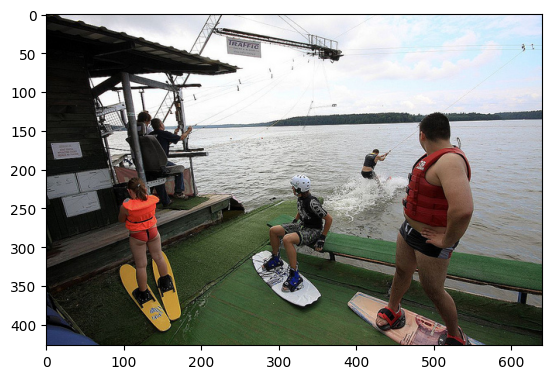

Ours:
 The scene depicts a group of people gathered on a boat, ready to waterski. There


In [20]:
plt.imshow(image)
plt.show()
print("Ours:\n", outputs)

In [21]:
evaluator = pickle.load(open("/data1/zhr/checkpoints/chair/cache.pkl", 'rb'))
cap_dict = evaluator.compute_sample_chair(outputs, image_id)
print(cap_dict)

{'image_id': 433554, 'caption': 'The scene depicts a group of people gathered on a boat, ready to waterski. There', 'mscoco_hallucinated_words': [], 'mscoco_gt_words': ['skis', 'chair', 'snowboard', 'person', 'bench', 'surfboard', 'boat'], 'mscoco_generated_words': ['person', 'boat'], 'hallucination_idxs': [], 'metrics': {'CHAIRs': 0, 'CHAIRi': 0.0, 'Recall': 0.2857142857142857, 'Len': 17}}


In [22]:
output_ids = output_dict.sequences
if kwargs.get("input_ids", None) is not None:
    input_token_len = kwargs["input_ids"].shape[1]
else:
    input_token_len = 0

target_word = "motorcycle"
start_idx = 12
outputs_tokens = output_ids[0, input_token_len:]
# words = tokenizer.decode(outputs_tokens[start_idx:start_idx+50]).encode("unicode_escape").decode()
for idx, token in enumerate(outputs_tokens[start_idx:]):
    word = tokenizer.decode(token)
    if word == target_word[:len(word)] and len(word) > 0:
        print(start_idx+idx, word, tokenizer.decode(outputs_tokens[start_idx+idx:start_idx+idx+10]))
        break


In [23]:
token_idx = 0
# token_idx = 16
threshold_top_k = 10
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

if model == "qwen-vl":
    layer_norm = model_loader.llm_model.transformer.ln_f
else:
    layer_norm = model_loader.llm_model.model.norm

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = layer_norm(hidden_states[layer_id])
        uncond_layer_output = layer_norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model_loader.llm_model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model_loader.llm_model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)

layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

In [ ]:
probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

candidate_tokens_probs, top_k_candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1).float()
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))   

candidate_tokens_ids = top_k_candidate_tokens_ids[:candidate_tokens_cutoff_idx]

candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]

top_k_words = [tokenizer.decode(t.cpu()) for t in top_k_candidate_tokens_ids]
top_p_words = [tokenizer.decode(t.cpu()) for t in candidate_tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()) for t in final_tokens_ids]

print("top_k_candidate_tokens\n", top_k_words)
print(candidate_tokens_probs)

print("top_p_candidate_tokens\n", top_p_words)
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

# print("next token logits\n", output_dict.next_token_scores[token_idx][...,candidate_tokens_ids])
# print("next token uncond logits\n", uncond_output_dict.scores[token_idx][...,candidate_tokens_ids])
# print("target layer logits\n", output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
# print("uncond target layer logits\n", uncond_output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
# print("Target Layer idx: ", output_dict.target_layers[token_idx])
# print("target layer max probs: ", output_dict.target_max_probs[token_idx])
# print("uncond target layer max probs: ", uncond_output_dict.target_max_probs[token_idx])
# print("final logits\n", output_dict.final_scores[token_idx][...,candidate_tokens_ids])


print("final_tokens\n", final_words)
print(final_tokens_probs)

top_k_candidate_tokens
 ['The', 'In', 'This', 'A', 'At', 'There', 'On', 'Several', 'People', 'It']
tensor([8.4766e-01, 1.3208e-01, 1.0666e-02, 4.5166e-03, 1.6880e-03, 1.1244e-03,
        6.5088e-04, 6.2084e-04, 2.0480e-04, 2.0158e-04], device='cuda:0',
       dtype=torch.float16, grad_fn=<TopkBackward0>)
top_p_candidate_tokens
 ['The', 'In']
tensor([0.8477, 0.1321], device='cuda:0', dtype=torch.float16,
       grad_fn=<SliceBackward0>)
next token logits
 tensor([[27.0938, 25.2344]], device='cuda:0')
next token uncond logits
 tensor([[22.4062, 20.9375]], device='cuda:0')
target layer logits
 tensor([[11.2734,  8.3438]], device='cuda:0', dtype=torch.float16)
uncond target layer logits
 tensor([[10.3672,  7.4180]], device='cuda:0', dtype=torch.float16)
Target Layer idx:  28
target layer max probs:  0.329345703125
uncond target layer max probs:  0.051849365234375
final logits
 tensor([[38.2734, 33.5156]], device='cuda:0')
final_tokens
 ['The', 'In', '<unk>', '<s>', '<0x03>', '<0x04>', '<0x

In [25]:
# cross layer JSD
M = 0.5 * (layer_softmax[...,candidate_tokens_ids] + uncond_layer_softmax[...,candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

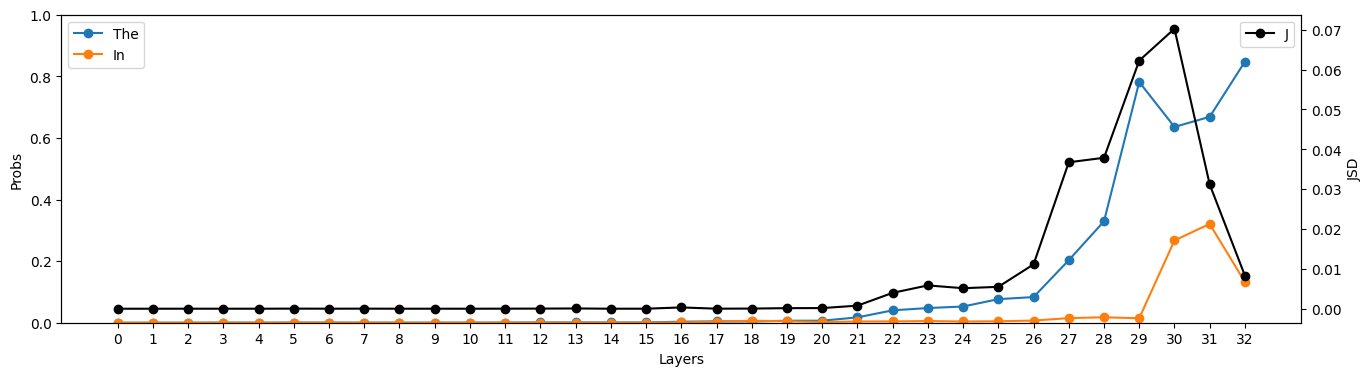

In [26]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(top_p_words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J", loc='upper right')

plt.show()
# print("Max JS divergence idx: ", jsd.argmax().item())
# print("Target Layer idx: ", output_dict.target_layers[token_idx])

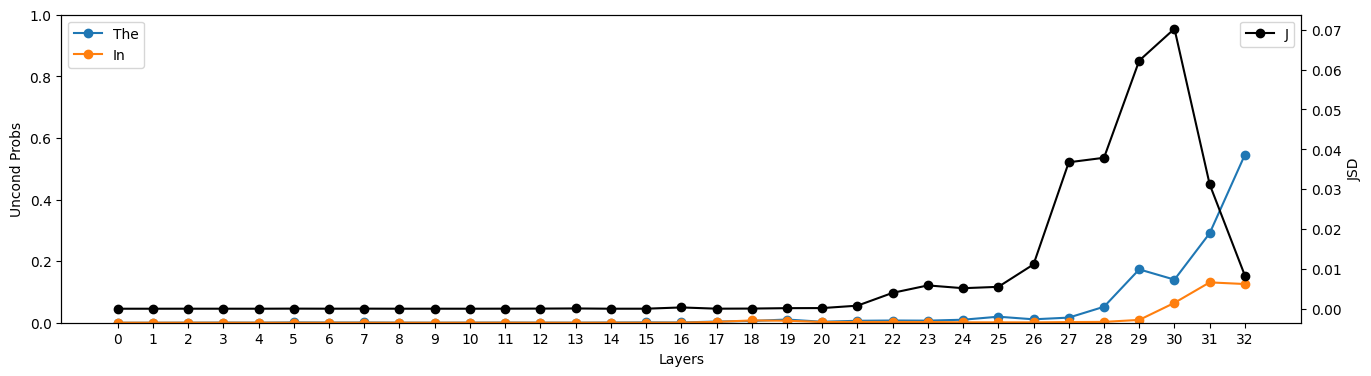

In [28]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Uncond Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(top_p_words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J", loc='upper right')

plt.show()